In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model


In [9]:
df=pd.read_excel('/content/drive/MyDrive/fuel_excel.xlsx')
df

,Fuel_Type,Adulterant,Adulteration_%,Density,Viscosity,Refractive_Index,Dielectric,Optical_Sensor,Color,Temperature,Flash_Point,Label
0,Petrol,NaN,0,763.458,0.756,1.3892,2.077,138.552,0.873,26.57,41.77,Pure
1,Kerosene,NaN,0,787.224,1.678,1.4475,2.532,144.418,0.658,23.08,49.78,Pure
2,Petrol,NaN,0,753.956,0.682,1.3980,2.349,139.134,0.841,23.44,44.85,Pure
3,Kerosene,NaN,0,790.992,2.418,1.4499,2.404,144.225,0.735,32.96,46.74,Pure
4,Diesel,NaN,0,845.347,4.329,1.4484,2.825,145.077,0.648,24.43,86.05,Pure
...,...,...,...,...,...,...,...,...,...,...,...,...
5595,Diesel,NaN,0,823.051,4.155,1.4411,2.446,143.958,0.519,29.56,83.71,Pure
5596,Diesel,WasteOil,30,874.352,5.245,1.4530,2.780,144.238,0.744,28.75,71.49,Adulterated
5597,Diesel,Water,10,850.016,3.768,1.4442,10.619,144.152,0.682,20.97,74.03,Adulterated
5598,Petrol,NaN,0,744.844,0.748,1.3961,2.172,139.921,0.855,28.79,36.06,Pure


In [10]:
print(df.columns)

Index(['Fuel_Type', 'Adulterant', 'Adulteration_%', 'Density', 'Viscosity',
       'Refractive_Index', 'Dielectric', 'Optical_Sensor', 'Color',
       'Temperature', 'Flash_Point', 'Label'],
      dtype='object')


In [11]:
#I checked in this dataset, any null values are present or not so the result is this .according to this dataset i have to check the fuel quality(Adulterant).if the value is 0.it is mean that the fuel is pure.
print(df.isnull().sum())



Fuel_Type              0
Adulterant          3600
Adulteration_%         0
Density                0
Viscosity              0
Refractive_Index       0
Dielectric             0
Optical_Sensor         0
Color                  0
Temperature            0
Flash_Point            0
Label                  0
dtype: int64


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5600 entries, 0 to 5599
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Fuel_Type         5600 non-null   object 
 1   Adulterant        2000 non-null   object 
 2   Adulteration_%    5600 non-null   int64  
 3   Density           5600 non-null   float64
 4   Viscosity         5600 non-null   float64
 5   Refractive_Index  5600 non-null   float64
 6   Dielectric        5600 non-null   float64
 7   Optical_Sensor    5600 non-null   float64
 8   Color             5600 non-null   float64
 9   Temperature       5600 non-null   float64
 10  Flash_Point       5600 non-null   float64
 11  Label             5600 non-null   object 
dtypes: float64(8), int64(1), object(3)
memory usage: 525.1+ KB


In [13]:
df.describe()

,Adulteration_%,Density,Viscosity,Refractive_Index,Dielectric,Optical_Sensor,Color,Temperature,Flash_Point
count,5600.000000,5600.000000,5600.000000,5600.000000,5600.000000,5600.000000,5600.000000,5600.000000,5600.000000
mean,8.214286,799.982316,2.188555,1.425709,4.289666,142.540773,0.755791,27.527637,54.515118
std,14.591802,44.936038,1.281482,0.028930,5.829631,3.050152,0.139946,4.308036,16.190203
min,0.000000,697.703000,0.599000,1.350500,1.853000,133.285000,0.472000,20.000000,16.820000
25%,0.000000,758.304250,0.750000,1.394600,2.281000,139.662500,0.644750,23.790000,42.545000
50%,0.000000,804.695000,2.098000,1.441200,2.536000,143.506000,0.740000,27.655000,51.680000
75%,10.000000,836.263000,3.271250,1.449600,2.854000,144.989000,0.871000,31.250000,63.390000
max,50.000000,961.272000,6.431000,1.469200,45.869000,149.315000,1.161000,35.000000,99.270000


In [14]:
x_name=['Adulterant','Density','Viscosity']
y_name=['Adulteration_%']
real_data= df.copy() #new copy generate from the real data

#missing values in 'Adulterant' by filling with 'None' category
real_data['Adulterant'] = real_data['Adulterant'].fillna('None')
real_data['Adulterant']





,Adulterant
0,None
1,None
2,None
3,None
4,None
...,...
5595,None
5596,WasteOil
5597,Water
5598,None


In [15]:
x_name = ['Density', 'Viscosity', 'Refractive_Index', 'Dielectric', 'Optical_Sensor', 'Color', 'Temperature', 'Flash_Point', 'Adulterant']
print(x_name)

['Density', 'Viscosity', 'Refractive_Index', 'Dielectric', 'Optical_Sensor', 'Color', 'Temperature', 'Flash_Point', 'Adulterant']


In [16]:
# Perform one-hot encoding on the 'Adulterant' column
#get_dummies()      #to convert in binary form (0,1)


adulterant_dummies = pd.get_dummies(real_data['Adulterant'], drop_first=True)
adulterant_dummies


,Ethanol,Kerosene,Methanol,None,Solvent,WasteOil,Water
0,False,False,False,True,False,False,False
1,False,False,False,True,False,False,False
2,False,False,False,True,False,False,False
3,False,False,False,True,False,False,False
4,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...
5595,False,False,False,True,False,False,False
5596,False,False,False,False,False,True,False
5597,False,False,False,False,False,False,True
5598,False,False,False,True,False,False,False


In [48]:
adulterant_dummies.loc[14]

,14
Ethanol,False
Kerosene,False
Methanol,False
None,True
Solvent,False
WasteOil,False
Water,False


In [23]:


# Combine numerical features ('Density', 'Viscosity') with the new one-hot encoded 'Adulterant' features
X = pd.concat([real_data[['Density', 'Viscosity','Refractive_Index', 'Dielectric', 'Optical_Sensor', 'Color', 'Temperature', 'Flash_Point',]], adulterant_dummies], axis=1)
y = real_data[y_name]
print(X.columns)

lr = linear_model.LinearRegression()
lr.fit(X, y)



Index(['Density', 'Viscosity', 'Refractive_Index', 'Dielectric',
       'Optical_Sensor', 'Color', 'Temperature', 'Flash_Point', 'Ethanol',
       'Kerosene', 'Methanol', 'None', 'Solvent', 'WasteOil', 'Water'],
      dtype='object')


LinearRegression()

In [24]:
lr.predict([[790.992,2.418,1.4499,2.404,144.225,0.735,32.96,46.740,0,0,0,1,0,0,0]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[2.24643646]])

In [25]:
lr.coef_

array([[-1.60148254e-02,  3.61121280e+00,  6.74299903e-01,
         1.59134468e+00,  1.55299552e-01,  2.68241980e+01,
         4.40514926e-02, -9.28003102e-02, -9.23711915e+00,
         2.66114050e-01, -1.17586183e+01, -2.28910792e+01,
        -9.51480647e-01, -6.72114221e+00, -2.88295998e+01]])

In [26]:

lr.intercept_

array([-14.95837234])

In [30]:
import numpy as np
custom_values = [790.992, 2.418, 1.4499, 2.404, 144.225, 0.735, 32.96, 46.74, 0, 0, 0, 1, 0, 0, 0]
coefficients = [-1.60148254e-02,  3.61121280e+00,  6.74299903e-01,1.59134468e+00,  1.55299552e-01,  2.68241980e+01,4.40514926e-02, -9.28003102e-02, -9.23711915e+00,2.66114050e-01, -1.17586183e+01, -2.28910792e+01,-9.51480647e-01, -6.72114221e+00, -2.88295998e+01]
intercept=[-14.95837234]
X_input = np.array(custom_values)
M_weights = np.array(coefficients[:len(custom_values)])

# Dot product + Intercept
prediction = np.dot(X_input, M_weights) + intercept
print(prediction)




[2.24643639]


In [34]:

print(f"Total Input Features Used:{len(X_input)}")
print(f"Predicted Output:{prediction[0]:.4f}")

# Model se direct prediction (cross-check ke liye)
model_prediction_check = lr.predict([custom_values])
print(f"Model's Direct Prediction: {model_prediction_check[0][0]:.4f}")

Total Input Features Used:15
Predicted Output:2.2464
Model's Direct Prediction: 2.2464


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [88]:
print("Model trained successfully!")
print("Intercept:", lr2.intercept_)
print("Coefficients:", lr2.coef_)

Model trained successfully!
Intercept: [-14.95837234]
Coefficients: [[-1.60148254e-02  3.61121280e+00  6.74299903e-01  1.59134468e+00
   1.55299552e-01  2.68241980e+01  4.40514926e-02 -9.28003102e-02
  -9.23711915e+00  2.66114050e-01 -1.17586183e+01 -2.28910792e+01
  -9.51480647e-01 -6.72114221e+00 -2.88295998e+01]]


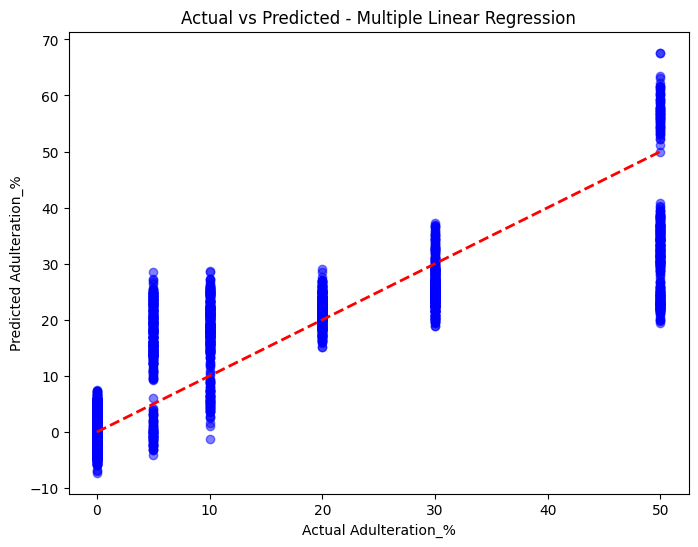

In [89]:
import matplotlib.pyplot as plt

# Predictions nikalo poore dataset ke liye
y_pred = lr2.predict(X)

# Actual vs Predicted scatter plot
plt.figure(figsize=(8,6))
plt.scatter(y, y_pred, color='blue', alpha=0.5)

# Perfect prediction line (45 degree line) - reference ke liye
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linewidth=2, linestyle='--')

plt.xlabel('Actual Adulteration_%')
plt.ylabel('Predicted Adulteration_%')
plt.title('Actual vs Predicted - Multiple Linear Regression')
plt.show()

In [83]:
r2 = r2_score(y, y_pred)
print("R² Score =", r2)

R² Score = 0.7611100481498159


In [84]:
mae = mean_absolute_error(y, y_pred)
print("MAE =", mae)

MAE = 4.425486774871475


In [85]:
mse = mean_squared_error(y, y_pred)
print("MSE =", mse)

MSE = 50.85552673953538


In [86]:
rmse = np.sqrt(mse)
print("RMSE =", rmse)

RMSE = 7.131306103340073
